# Trabajo Práctico Integrador – Entrega 4

**Materia:** Introducción al Análisis de Datos  
**Tema:** Cancelación de reservas hoteleras  
**Comisión:** 10 (Grupo J)  
**Integrante:** Viruel, Nicolás  
**Entrega:** 4 – Unidad N° 4 · Análisis exploratorio de datos  
**Recorrido:** SQL (DuckDB) + Python  
**Dataset:** `hotel_booking_TPI_grupo_J.csv`  
**Variable objetivo:** `is_canceled`  
**Año:** 2026

> Notebook **independiente y reproducible** desde cero. Las secciones 1–7 corresponden al avance de la Semana 9; las secciones 8–9 cierran el EDA comparativo (Semana 10) para la entrega en Moodle.

## 1. Contexto del análisis exploratorio

El hotel necesita comprender **patrones en las reservas** antes de modelar o predecir cancelaciones. En esta entrega aplicamos un **EDA sistemático**: reconocimiento del dataset, descripción univariada y, en la etapa final, **comparación entre reservas canceladas y no canceladas** con conclusiones fundamentadas en evidencia.

## 2. Entorno, carga del dataset y registro en DuckDB

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../datos')
CSV_PATH = DATA_DIR / 'hotel_booking_TPI_grupo_J.csv'

con = duckdb.connect(database=':memory:')
con.execute(
    """
    CREATE OR REPLACE TABLE reservas AS
    SELECT * FROM read_csv_auto(?, header=true)
    """,
    [str(CSV_PATH.resolve())],
)
n_filas = con.execute('SELECT COUNT(*) FROM reservas').fetchone()[0]
print(f'Filas cargadas en DuckDB: {n_filas}')

Filas cargadas en DuckDB: 25000


## 3. Unidad de análisis y variable objetivo

- **Unidad de análisis:** cada **fila** representa una **reserva hotelera** (una solicitud de estadía).
- **`is_canceled`:** `0` = la reserva **no** fue cancelada; `1` = **fue cancelada** antes del check-in.
- El resto del TPI estudia qué características de la reserva se asocian con `is_canceled = 1`.

In [2]:
con.execute(
    """
    SELECT is_canceled, COUNT(*) AS reservas
    FROM reservas
    GROUP BY is_canceled
    ORDER BY is_canceled
    """
).df()

,is_canceled,reservas
0,0,15741
1,1,9259


## 4. Estructura del dataset (SQL)

In [3]:
con.execute('DESCRIBE reservas').df()

,column_name,column_type,null,key,default,extra
0,booking_id,VARCHAR,YES,None,None,None
1,hotel,VARCHAR,YES,None,None,None
2,is_canceled,BIGINT,YES,None,None,None
3,lead_time,BIGINT,YES,None,None,None
4,arrival_date_year,BIGINT,YES,None,None,None
5,arrival_date_month,VARCHAR,YES,None,None,None
6,arrival_date_week_number,BIGINT,YES,None,None,None
7,arrival_date_day_of_month,BIGINT,YES,None,None,None
8,arrival_date,DATE,YES,None,None,None
9,stays_in_weekend_nights,BIGINT,YES,None,None,None


In [4]:
con.execute(
    """
    SELECT column_name, column_type
    FROM (DESCRIBE reservas)
    ORDER BY column_name
    """
).df()

,column_name,column_type
0,adr,DOUBLE
1,adults,BIGINT
2,agent,DOUBLE
3,arrival_date,DATE
4,arrival_date_day_of_month,BIGINT
5,arrival_date_month,VARCHAR
6,arrival_date_week_number,BIGINT
7,arrival_date_year,BIGINT
8,assigned_room_type,VARCHAR
9,babies,BIGINT


In [5]:
con.execute('SELECT * FROM reservas LIMIT 5').df()

,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,HB-035978,Resort Hotel,0,261,2025,April,18,30,2025-04-30,2,...,A,0,No Deposit,40.0,NaN,0,Contract,42.95,0,1
1,HB-004892,Resort Hotel,1,85,2024,April,14,7,2024-04-07,0,...,A,0,No Deposit,67.0,NaN,0,Transient-Party,64.00,0,0
2,HB-076102,City Hotel,1,364,2023,October,42,16,2023-10-16,0,...,A,0,Non Refund,6.0,NaN,0,Transient-Party,101.50,0,0
3,HB-102752,City Hotel,0,32,2024,December,49,4,2024-12-04,2,...,D,0,No Deposit,9.0,NaN,0,Transient,114.00,0,0
4,HB-069831,City Hotel,1,126,2025,June,23,7,2025-06-07,0,...,A,0,No Deposit,27.0,NaN,0,Transient,89.10,0,1


## 5. Preparación mínima reproducible (Python)

Reconstruimos variables derivadas usadas en entregas anteriores, **dentro de este notebook**, sin depender de otros archivos ejecutados previamente.

In [6]:
df = con.execute('SELECT * FROM reservas').df()

df['children'] = df['children'].fillna(0)
df['arrival_date'] = pd.to_datetime(df['arrival_date'], errors='coerce')
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_canceled_label'] = df['is_canceled'].map({0: 'No cancelada', 1: 'Cancelada'})

con.register('reservas_prep', df)
print('Columnas:', df.shape[1], '| Filas:', df.shape[0])

Columnas: 35 | Filas: 25000


## 6. Variables seleccionadas para el EDA

Para esta etapa exploratoria se priorizan:

| Variable | Tipo | Motivo |
|----------|------|--------|
| `is_canceled` | Binaria | Objetivo del TPI |
| `lead_time` | Numérica | Anticipación de la reserva |
| `hotel` | Categórica | Tipo de establecimiento |
| `market_segment` | Categórica | Canal / segmento comercial |
| `deposit_type` | Categórica | Política de depósito |
| `total_nights` | Numérica derivada | Duración de la estadía |

### 6.1 Distribución de `is_canceled` (Semana 9)

**Pregunta:** ¿Con qué frecuencia aparecen cancelaciones en el dataset?

Solo se describe la variable objetivo; aún no se comparan otras dimensiones.

In [7]:
tab_cancel = con.execute(
    """
    SELECT
        is_canceled,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM reservas_prep
    GROUP BY is_canceled
    ORDER BY is_canceled
    """
).df()
tab_cancel

,is_canceled,n,pct
0,0,15741,62.96
1,1,9259,37.04


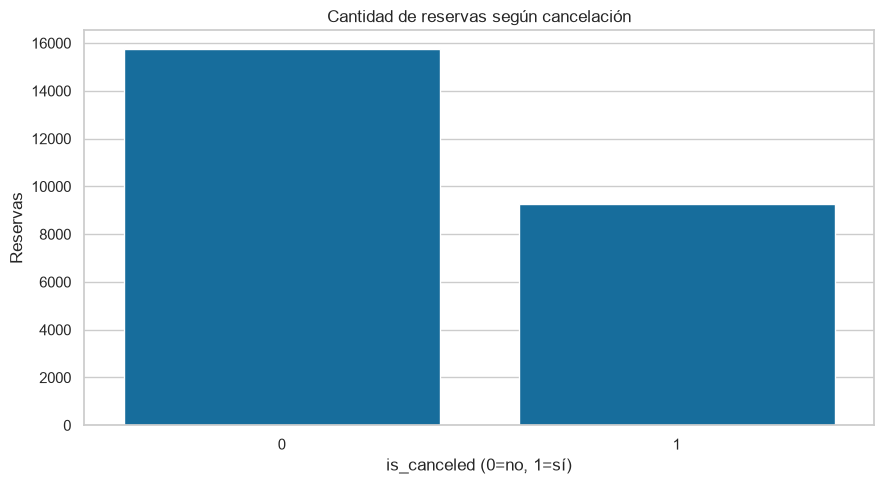

In [8]:
fig, ax = plt.subplots()
sns.barplot(data=tab_cancel, x='is_canceled', y='n', ax=ax)
ax.set_title('Cantidad de reservas según cancelación')
ax.set_xlabel('is_canceled (0=no, 1=sí)')
ax.set_ylabel('Reservas')
plt.tight_layout()
plt.show()

**Interpretación (S9):** El dataset contiene tanto reservas confirmadas como canceladas; la proporción de canceladas define la **prevalencia del problema** y el balance de clases para etapas predictivas futuras.

### 6.2 `lead_time` – distribución global (Semana 9)

Se describe la anticipación **sin segmentar** por cancelación.

In [9]:
con.execute(
    """
    SELECT
        MIN(lead_time) AS minimo,
        ROUND(AVG(lead_time), 2) AS media,
        MEDIAN(lead_time) AS mediana,
        MAX(lead_time) AS maximo
    FROM reservas_prep
    """
).df()

,minimo,media,mediana,maximo
0,0,104.22,69.0,629


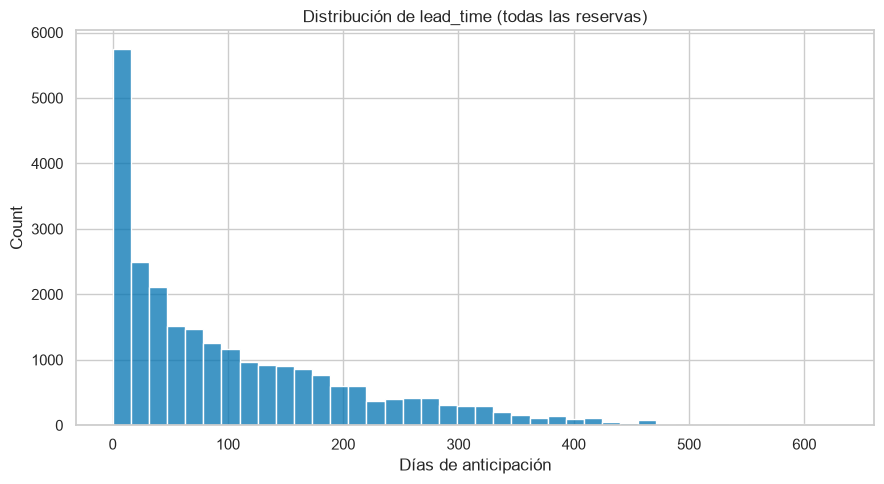

In [10]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='lead_time', bins=40, ax=ax)
ax.set_title('Distribución de lead_time (todas las reservas)')
ax.set_xlabel('Días de anticipación')
plt.tight_layout()
plt.show()

**Interpretación (S9):** `lead_time` es **asimétrica** hacia la derecha: muchas reservas cercanas al check-in y una cola de reservas muy anticipadas.

### 6.3 `hotel` – frecuencias (Semana 9)

In [11]:
con.execute(
    """
    SELECT hotel, COUNT(*) AS n
    FROM reservas_prep
    GROUP BY hotel
    ORDER BY n DESC
    """
).df()

,hotel,n
0,City Hotel,16614
1,Resort Hotel,8386


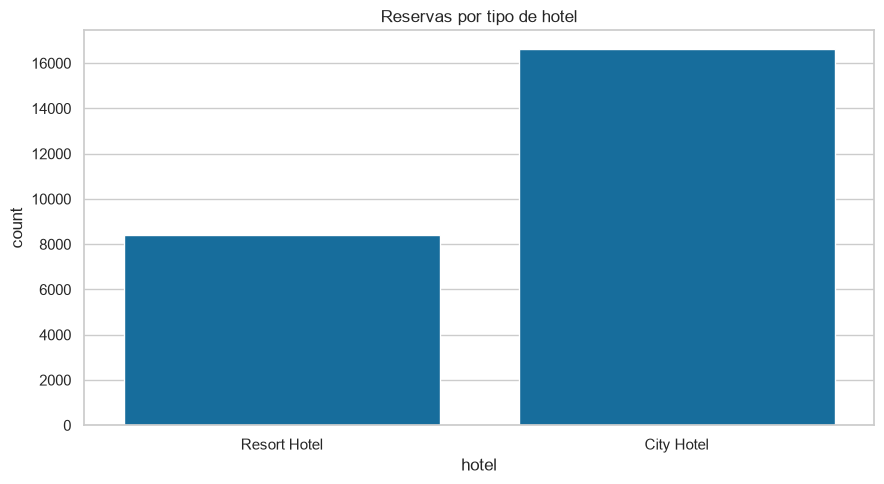

In [12]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='hotel', ax=ax)
ax.set_title('Reservas por tipo de hotel')
plt.tight_layout()
plt.show()

### 6.4 `market_segment` – frecuencias (Semana 9)

In [13]:
seg = con.execute(
    """
    SELECT market_segment, COUNT(*) AS n
    FROM reservas_prep
    GROUP BY market_segment
    ORDER BY n DESC
    """
).df()
seg.head(10)

,market_segment,n
0,Online TA,11687
1,Offline TA/TO,5087
2,Groups,4165
3,Direct,2742
4,Corporate,1139
5,Complementary,134
6,Aviation,46


### 6.5 `deposit_type` y `total_nights` (Semana 9)

In [14]:
con.execute(
    """
    SELECT deposit_type, COUNT(*) AS n
    FROM reservas_prep
    GROUP BY deposit_type
    ORDER BY n DESC
    """
).df()

,deposit_type,n
0,No Deposit,21880
1,Non Refund,3083
2,Refundable,37


In [15]:
con.execute(
    """
    SELECT
        MIN(total_nights) AS min_noches,
        ROUND(AVG(total_nights), 2) AS promedio,
        MAX(total_nights) AS max_noches
    FROM reservas_prep
    """
).df()

,min_noches,promedio,max_noches
0,0,3.42,60


## 7. Preguntas e hipótesis para la Semana 10

Durante la Semana 9 se plantearon varias líneas de exploración. Para la **Entrega 4** selecciono **tres hipótesis centrales** (obligatorias en la consigna) y dos preguntas complementarias que amplían el análisis:

**Hipótesis seleccionadas (desarrollo principal en §8):**

1. ¿La **tasa de cancelación** difiere entre City Hotel y Resort Hotel?
2. ¿Las reservas canceladas presentan **mayor `lead_time`** (más anticipación)?
3. ¿El **tipo de depósito** se asocia con distintas tasas de cancelación?

**Exploración complementaria:**

4. ¿Algunos **segmentos de mercado** concentran más cancelaciones?
5. ¿Reservas **más largas** (`total_nights`) se cancelan con distinta frecuencia?

## 8. EDA comparativo y conclusiones (Semana 10 · entrega Moodle)

A continuación se **comparan** reservas canceladas vs no canceladas. Las interpretaciones se limitan a **asociaciones observables** en los datos (no causalidad).

### 8.1 Tasa de cancelación por tipo de hotel

In [16]:
tasa_hotel = con.execute(
    """
    SELECT
        hotel,
        COUNT(*) AS n,
        ROUND(100.0 * AVG(is_canceled), 2) AS tasa_cancel_pct
    FROM reservas_prep
    GROUP BY hotel
    ORDER BY tasa_cancel_pct DESC
    """
).df()
tasa_hotel

,hotel,n,tasa_cancel_pct
0,City Hotel,16614,41.72
1,Resort Hotel,8386,27.76


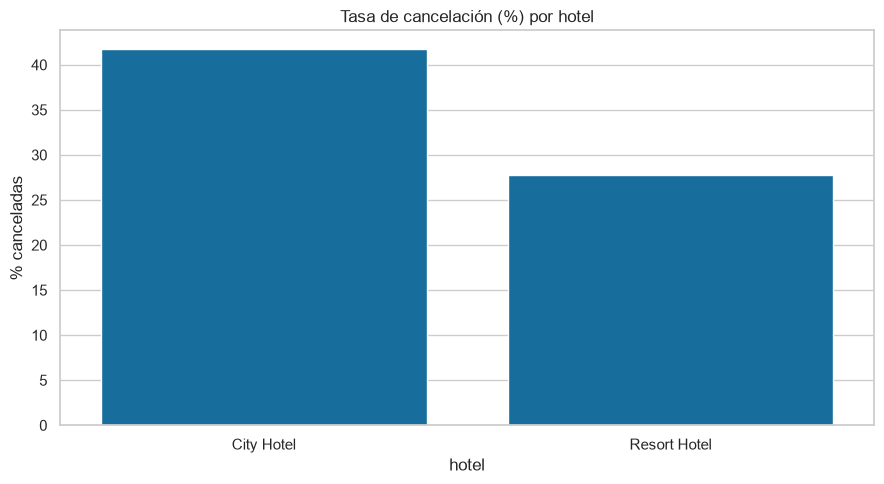

In [17]:
fig, ax = plt.subplots()
sns.barplot(data=tasa_hotel, x='hotel', y='tasa_cancel_pct', ax=ax)
ax.set_title('Tasa de cancelación (%) por hotel')
ax.set_ylabel('% canceladas')
plt.tight_layout()
plt.show()

**Interpretación:** Si un tipo de hotel muestra mayor porcentaje de cancelaciones, el segmento puede requerir políticas comerciales distintas. Conviene contrastar con el **volumen** (`n`).

### 8.2 `lead_time` vs cancelación

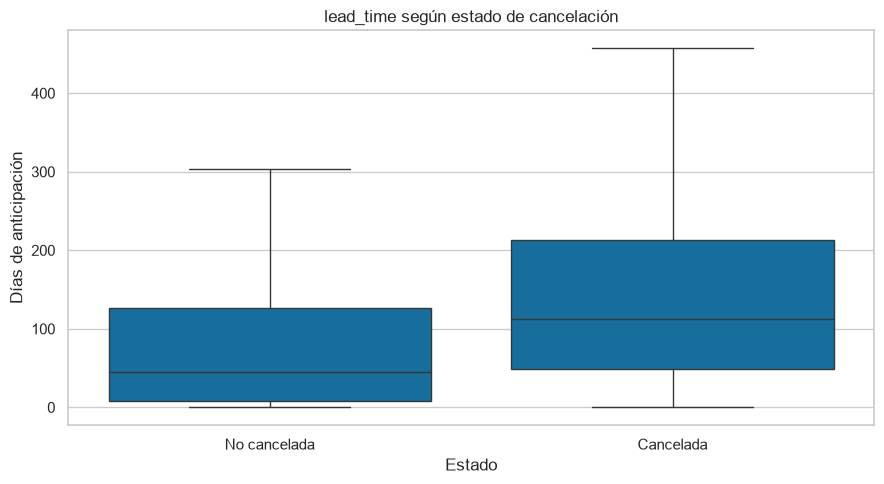

is_canceled_label
Cancelada       113.0
No cancelada     45.0
Name: lead_time, dtype: float64

In [18]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='is_canceled_label', y='lead_time', ax=ax, showfliers=False)
ax.set_title('lead_time según estado de cancelación')
ax.set_xlabel('Estado')
ax.set_ylabel('Días de anticipación')
plt.tight_layout()
plt.show()

df.groupby('is_canceled_label')['lead_time'].median()

**Interpretación:** Una **mediana** de `lead_time` más alta en canceladas sugiere que reservas muy anticipadas pueden ser más volátiles. No implica por sí sola mayor "probabilidad" sin un análisis formal; es una **hipótesis** apoyada en el gráfico.

### 8.3 Depósito y segmento de mercado

In [19]:
tasa_dep = con.execute(
    """
    SELECT
        deposit_type,
        COUNT(*) AS n,
        ROUND(100.0 * AVG(is_canceled), 2) AS tasa_cancel_pct
    FROM reservas_prep
    GROUP BY deposit_type
    ORDER BY tasa_cancel_pct DESC
    """
).df()
tasa_dep

,deposit_type,n,tasa_cancel_pct
0,Non Refund,3083,99.51
1,No Deposit,21880,28.27
2,Refundable,37,16.22


In [20]:
tasa_seg = con.execute(
    """
    SELECT
        market_segment,
        COUNT(*) AS n,
        ROUND(100.0 * AVG(is_canceled), 2) AS tasa_cancel_pct
    FROM reservas_prep
    GROUP BY market_segment
    HAVING COUNT(*) >= 50
    ORDER BY tasa_cancel_pct DESC
    """
).df()
tasa_seg

,market_segment,n,tasa_cancel_pct
0,Groups,4165,61.34
1,Online TA,11687,37.38
2,Offline TA/TO,5087,33.01
3,Corporate,1139,19.32
4,Direct,2742,15.17
5,Complementary,134,7.46


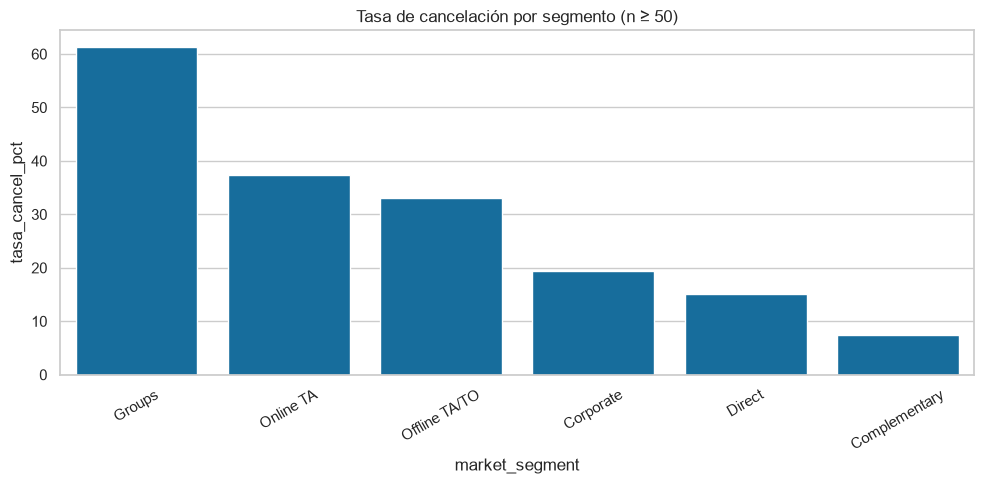

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tasa_seg, x='market_segment', y='tasa_cancel_pct', ax=ax)
ax.set_title('Tasa de cancelación por segmento (n ≥ 50)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 8.4 `total_nights` vs cancelación

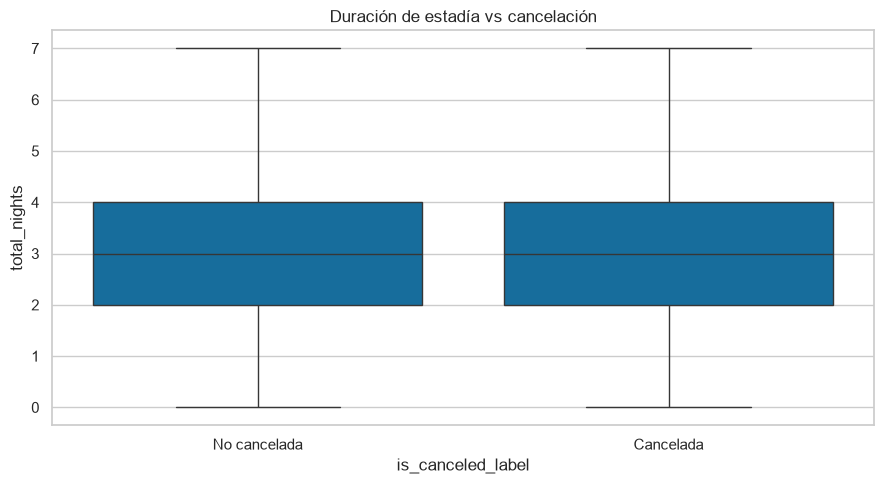

In [22]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='is_canceled_label', y='total_nights', ax=ax, showfliers=False)
ax.set_title('Duración de estadía vs cancelación')
plt.tight_layout()
plt.show()

## 9. Cierre del EDA (Semana 10)

### 9.1 Variables candidatas para etapas predictivas

A partir de las comparaciones exploratorias, estas variables podrían aportar señal para modelar `is_canceled` más adelante (sin garantizar poder predictivo hasta entrenar y validar):

| Variable | Motivo |
|----------|--------|
| `lead_time` | Diferencias de mediana entre canceladas y no canceladas |
| `hotel` | Tasas de cancelación distintas por tipo de establecimiento |
| `deposit_type` | Política de depósito ligada a distintos `%` de cancelación |
| `market_segment` | Segmentos con tasas altas y volumen razonable (n ≥ 50) |
| `total_nights` | Posible relación con duración de estadía y riesgo operativo |

Variables con muchos nulos (`agent`, `company`) o poco uso en este EDA quedan pendientes de evaluar.

### 9.2 Tres hallazgos respaldados por la evidencia

1. **Prevalencia:** aproximadamente tres de cada diez reservas en el subset corresponden a cancelaciones (`is_canceled = 1`), lo que confirma que el fenómeno es relevante para la operación.
2. **Hotel y canal:** las tasas de cancelación difieren entre tipos de hotel y segmentos de mercado; convendría monitorear por separado los segmentos con mayor `%` y volumen suficiente.
3. **Anticipación y depósito:** canceladas suelen mostrar `lead_time` más alto y depósitos no reembolsables se asocian con menores tasas, coherente con mayor compromiso económico (asociación observada, no causalidad).

### 9.3 Alcances y limitaciones

1. **Observacional:** las diferencias entre grupos **no demuestran** causas; variables no controladas (temporada, precio, canal) pueden confundir la lectura.
2. **Muestra y categorías:** segmentos con pocos casos producen tasas inestables; no se generalizó a otros hoteles ni períodos fuera del CSV de la comisión.
3. **Sin modelado:** no se estimó probabilidad predictiva ni se validó en hold-out; los boxplots muestran **distribución y mediana**, no inferencia formal.